# CCM-109 - Tópicos especiais de IA - Deep Learning

## Pipeline de detecção de deepfake

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jtlimo/ccm-109/blob/main/train.ipynb)

---

### Índice

1. [Configuração](#1-configuração)
2. [Dataset FF++](#2-dataset-faceforensics)
3. [Funções auxiliares](#3-funções-auxiliares)
4. [Treino](#4-treino)

## 1. Configuração

In [1]:
# @title Instala dependências

%pip install -q tensorflow keras-hub numpy opencv-python matplotlib scikit-learn mtcnn ipywidgets tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 130.9 MB/s eta 0:00:00


In [83]:
# @title Imports

import os
import glob
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score,\
confusion_matrix, f1_score, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import model as m
import preprocess as pi
import keras_hub

In [13]:
# @title Configurações

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 30
MIXUP_STOP_EPOCH = int(EPOCHS * 0.4)
LR = 1e-4
FEATURE_DIM = 768
DATASET_ROOT = "/content/drive/MyDrive/dataset/ff_frames"
DATASET_LOCAL = "/content/dataset_local"
FEATURES_CACHE = "/content/drive/MyDrive/dataset/FF_Features_Cache"
BACKBONE_CACHE = "/content/drive/MyDrive/dataset"

import tensorflow as tf
from tensorflow import keras

AUTOTUNE = tf.data.AUTOTUNE

print(f"GPUs visíveis: {tf.config.list_physical_devices('GPU')}")
print(f'TensorFlow: {tf.__version__}')

GPUs visíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow: 2.20.0


## 2. Dataset FaceForensics++

No arquivo **face_extraction.ipynb** foi realizada a extração dos rostos frame por frame nos vídeos do dataset. Para melhorar a otimização, foram utilizados os seguintes filtros na extração:

- SKIP_FRAMES = 9     
_0 = todos; 9 = pula 9 (processa 1 a cada 10)_

- MAX_FRAMES_PER_VIDEO = 30          
_None = todos; ex: 100 = máx 100 frames que contenham rostos são salvos_

- MAX_READ_LIMIT = 1000                 
_None = todos; ex: 1000 = máx 1000 frames lidos por vídeo_

- MAX_VIDEOS = None                 
_None = todos; ex: 10 = máx 10 vídeos processados_


| Índice | Classe
|---|---
| 0 | real
| 1 | fake

Há também o pré-processamento para o siglip2 que é o que será usado no modelo, as imagens são salvas em 224x224 (float 32)

## 3. Funções auxiliares

In [4]:
#@title Configuração do Feature MixUp
use_mixup = tf.Variable(True, trainable=False, dtype=tf.bool)

def sample_beta_distribution(shape, alpha=0.2):
    gamma_1 = tf.random.gamma(shape, alpha)
    gamma_2 = tf.random.gamma(shape, alpha)
    return gamma_1 / (gamma_1 + gamma_2 + 1e-8)

def apply_early_stopped_mixup(batch_1, batch_2, alpha=0.2):
    x1, y1 = batch_1
    x2, y2 = batch_2

    def mixup_fn():
        batch_size = tf.shape(x1)[0]
        l = sample_beta_distribution([batch_size, 1], alpha=alpha)

        x_mixed = l * tf.cast(x1, tf.float32) + (1.0 - l) * tf.cast(x2, tf.float32)
        y_mixed = l * tf.cast(tf.reshape(y1, (-1, 1)), tf.float32) + (1.0 - l) * tf.cast(tf.reshape(y2, (-1, 1)), tf.float32)

        return x_mixed, y_mixed

    def standard_fn():
        return tf.cast(x1, tf.float32), tf.cast(tf.reshape(y1, (-1, 1)), tf.float32)


    return tf.cond(use_mixup, mixup_fn, standard_fn)


class EarlyStoppedMixupCallback(keras.callbacks.Callback):
    def __init__(self, stop_epoch):
        super().__init__()
        self.stop_epoch = stop_epoch

    def on_epoch_begin(self, epoch, logs=None):
        if epoch >= self.stop_epoch:
            use_mixup.assign(False)
            print(f"\n🛑 [Early-Stopped Mixup] Época {epoch+1}: Mixup DESATIVADO. Ajustando fronteira com rótulos puros (ERM).")
        else:
            use_mixup.assign(True)
            print(f"\n🔀 [Early-Stopped Mixup] Época {epoch+1}: Mixup ATIVO. Extraindo características raras.")

In [14]:
#@title Verifica se o backbone existe localmente
backbone_path = os.path.join(BACKBONE_CACHE, "siglip2_base_patch16_224_original_backbone.keras")

if os.path.exists(backbone_path):
   print("Carregando backbone do SigLIP2 a partir do arquivo salvo...")
   try:
        backbone = keras.models.load_model(backbone_path)
   except Exception as e:
        print(f"Erro ao carregar o backbone localmente: {e}")
        print("Recarregando o backbone do SigLIP2 a partir do preset...")
        backbone = keras_hub.models.SigLIPBackbone.from_preset("siglip2_base_patch16_224")
        backbone.trainable = False
else:
  print("Baixando o backbone SigLIP2 do KerasHub...")
  backbone = keras_hub.models.SigLIPBackbone.from_preset("siglip2_base_patch16_224")
  backbone.trainable = False
  backbone.save(backbone_path)
  print("Salvo localmente")

Baixando o backbone SigLIP2 do KerasHub...
Salvo localmente


In [6]:
# @title Carrega Siglip2 sem a cabeça classificadora
def extract_features(file_paths, backbone_model, batch_size=64):
    features = []
    total = len(file_paths)

    for i in range(0, total, batch_size):
        batch_files = file_paths[i:i+batch_size]
        batch_imgs = np.stack([np.load(f) for f in batch_files], dtype=np.float32)

        batch_feats = backbone_model.get_vision_embeddings(batch_imgs)
        features.append(batch_feats.numpy())

    return np.concatenate(features, axis=0) if len(features) > 0 else np.array([])


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
# @title Carrega imagens pré-processadas para o Siglip2
def load_dataset_metadata(dataset_dir):
  file_paths, labels, video_ids = [], [], []
  search_path = os.path.join(dataset_dir, "**", "*.npy")

  for filepath in glob.glob(search_path, recursive=True):
        if "__MACOSX" in filepath or os.path.basename(filepath).startswith("._"):
            continue

        if os.path.getsize(filepath) < 1024:
            continue

        try:
            with open(filepath, "rb") as f:
                magic = f.read(6)
                if magic != b"\x93NUMPY":
                    continue
        except Exception:
            continue

        path_parts = filepath.split(os.sep)
        full_path_str = filepath.lower()

        label = 1 if any(kw in full_path_str for kw in ["fake", "manipulated", "deepfake", "face", "neural"]) else 0

        raw_video_id = path_parts[-2] if len(path_parts) >= 2 else "unknown"
        video_id = f"{'fake' if label == 1 else 'real'}_{raw_video_id}"

        file_paths.append(filepath)
        labels.append(label)
        video_ids.append(video_id)

  return np.array(file_paths), np.array(labels), np.array(video_ids)



In [11]:
#@title Descompacta arquivos e extrai features

import shutil

search_path = os.path.join(DATASET_ROOT, "**", "*.zip")
zip_files = sorted(glob.glob(search_path, recursive=True))

for idx, zip_path in enumerate(zip_files, 1):
    zip_name = os.path.basename(zip_path)
    output_npz_name = zip_name.replace(".zip", "_features.npz")
    output_npz_path = os.path.join(FEATURES_CACHE, output_npz_name)

    if os.path.exists(output_npz_path):
        print(f"⏩ [{idx}/{len(zip_files)}] {zip_name} já foi processado. Pulando...")
        continue

    print("=" * 70)
    print(f"🚀 [{idx}/{len(zip_files)}] Processando: {zip_name}")
    print("=" * 70)

    if os.path.exists(DATASET_LOCAL):
        shutil.rmtree(DATASET_LOCAL)
    os.makedirs(DATASET_LOCAL, exist_ok=True)

    temp_zip = "/content/temp_chunk.zip"
    print(" 1. Copiando .zip para o SSD da VM...")
    !cp "{zip_path}" "{temp_zip}"

    print(" 2. Descompactando arquivos .npy...")
    !unzip -q "{temp_zip}" -d "{DATASET_LOCAL}"
    os.remove(temp_zip)

    macosx_path = os.path.join(DATASET_LOCAL, "__MACOSX")
    if os.path.exists(macosx_path):
        shutil.rmtree(macosx_path)

    file_paths, labels, video_ids = load_dataset_metadata(DATASET_LOCAL)
    print(f" 3. Arquivos .npy encontrados: {len(file_paths):,} | Reais (0): {np.sum(labels == 0)} | Fakes (1): {np.sum(labels == 1)}")

    if len(file_paths) == 0:
        print(" ⚠️ Nenhum arquivo .npy válido encontrado neste zip. Pulando...")
        shutil.rmtree(DATASET_LOCAL)
        continue

    print(" 4. Extraindo embeddings (SigLIP2 768D)...")
    try:
        features = extract_features(file_paths, backbone, batch_size=BATCH_SIZE)
    except EOFError as e:
        print(f" ❌ Erro ao extrair features do {zip_name}: {e}. O arquivo .zip pode conter arquivos .npy corrompidos. Pulando...")
        shutil.rmtree(DATASET_LOCAL)
        continue

    print(f" 💾 Salvando cache em: {output_npz_name}...")
    np.savez_compressed(
        output_npz_path,
        features=features,
        labels=labels,
        video_ids=video_ids
    )

    shutil.rmtree(DATASET_LOCAL)
    tf.keras.backend.clear_session()
    print(" ✅ Concluído\n")

print("🎉 Todos os arquivos .zip de .npy foram convertidos em caches .npz")

⏩ [1/8] DeepFakeDetection.zip já foi processado. Pulando...
⏩ [2/8] Deepfakes.zip já foi processado. Pulando...
🚀 [3/8] Processando: Face2Face.zip
 1. Copiando .zip para o SSD da VM...
 2. Descompactando arquivos .npy...
 3. Arquivos .npy encontrados: 29,247 | Reais (0): 0 | Fakes (1): 29247
 4. Extraindo embeddings (SigLIP2 768D)...
 💾 Salvando cache em: Face2Face_features.npz...
 ✅ Concluído

🚀 [4/8] Processando: FaceShifter.zip
 1. Copiando .zip para o SSD da VM...
 2. Descompactando arquivos .npy...
 3. Arquivos .npy encontrados: 29,307 | Reais (0): 0 | Fakes (1): 29307
 4. Extraindo embeddings (SigLIP2 768D)...
 💾 Salvando cache em: FaceShifter_features.npz...
 ✅ Concluído

🚀 [5/8] Processando: FaceSwap.zip
 1. Copiando .zip para o SSD da VM...
 2. Descompactando arquivos .npy...
 3. Arquivos .npy encontrados: 29,170 | Reais (0): 0 | Fakes (1): 29170
 4. Extraindo embeddings (SigLIP2 768D)...
 💾 Salvando cache em: FaceSwap_features.npz...
 ✅ Concluído

🚀 [6/8] Processando: NeuralT

In [63]:
# @title Carregamento dos Embeddings e Divisão em Treino, Validação e Teste

npz_files = sorted(glob.glob(os.path.join(FEATURES_CACHE, "*_features.npz")))
print(f"📦 Encontrados {len(npz_files)} arquivos de features .npz no cache.")

if not npz_files:
    raise FileNotFoundError(f"Nenhum arquivo .npz encontrado em {FEATURES_CACHE}. Execute o processamento dos arquivos .zip primeiro.")

all_features, all_labels, all_vids = [], [], []

for npz_path in npz_files:
    data = np.load(npz_path)
    all_features.append(data["features"])
    all_labels.append(data["labels"])
    all_vids.append(data["video_ids"])

X = np.concatenate(all_features, axis=0)
y = np.concatenate(all_labels, axis=0)
vids = np.concatenate(all_vids, axis=0)

print(f"\n✅ Total de embeddings em RAM: {X.shape} ({X.nbytes / 1e6:.1f} MB)")
print(f"Distribuição total - Reais (0): {np.sum(y == 0):,} | Fakes (1): {np.sum(y == 1):,}")

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_val_idx, test_idx = next(gss_test.split(X, y, groups=vids))

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
train_sub_idx, val_sub_idx = next(gss_val.split(X[train_val_idx], y[train_val_idx], groups=vids[train_val_idx]))

real_train_idx = train_val_idx[train_sub_idx]
real_val_idx   = train_val_idx[val_sub_idx]

X_train, y_train, video_ids_train = X[real_train_idx], y[real_train_idx], vids[real_train_idx]
X_val, y_val, video_ids_val = X[real_val_idx], y[real_val_idx], vids[real_val_idx]
X_test, y_test, video_ids_test   = X[test_idx], y[test_idx], vids[test_idx]

print("\n" + "=" * 50)
print(f"Splits Finais:")
print(f"  • Treino:    {X_train.shape[0]:,} amostras")
print(f"  • Validação: {X_val.shape[0]:,} amostras")
print(f"  • Teste:     {X_test.shape[0]:,} amostras")
print("=" * 50)

📦 Encontrados 8 arquivos de features .npz no cache.

✅ Total de embeddings em RAM: (221681, 768) (681.0 MB)
Distribuição total - Reais (0): 41,837 | Fakes (1): 179,844

Splits Finais:
  • Treino:    155,135 amostras
  • Validação: 32,068 amostras
  • Teste:     34,478 amostras


## 4. Treino

## Modelo Temporal

In [72]:
#@title Cria sequencias por video

import numpy as np

def create_sequences_by_video(X, y, video_ids, sequence_length=30):
    X_seq, y_seq = [], []
    unique_videos = np.unique(video_ids)

    for vid in unique_videos:
        mask = (video_ids == vid)
        X_vid = X[mask]
        y_vid = y[mask][0]


        if len(X_vid) >= sequence_length:
            indices = np.linspace(0, len(X_vid) - 1, sequence_length, dtype=int)
            X_seq.append(X_vid[indices])
            y_seq.append(y_vid)

    return np.array(X_seq), np.array(y_seq)

SEQUENCE_LENGTH = 30

X_train_seq, y_train_seq = create_sequences_by_video(X_train, y_train, video_ids_train, sequence_length=SEQUENCE_LENGTH)
X_val_seq, y_val_seq     = create_sequences_by_video(X_val, y_val, video_ids_val, sequence_length=SEQUENCE_LENGTH)
X_test_seq, y_test_seq   = create_sequences_by_video(X_test, y_test, video_ids_test, sequence_length=SEQUENCE_LENGTH)

print(f"Shape Treino Temporal: {X_train_seq.shape}")
print(f"Shape Validação Temporal: {X_val_seq.shape}")
print(f"Shape Teste Temporal: {X_test_seq.shape}")

Shape Treino Temporal: (2150, 30, 768)
Shape Validação Temporal: (460, 30, 768)
Shape Teste Temporal: (453, 30, 768)


In [73]:
#@title Criação do dataset / build classificador temporal / treinamento

from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import importlib
import model as m

importlib.reload(m)

BATCH_SIZE = 32

train_ds_seq = tf.data.Dataset.from_tensor_slices((X_train_seq, y_train_seq)) \
    .shuffle(1000, seed=42) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds_seq = tf.data.Dataset.from_tensor_slices((X_val_seq, y_val_seq)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds_seq = tf.data.Dataset.from_tensor_slices((X_test_seq, y_test_seq)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

temporal_classifier = m.build_temporal_classifier(
    sequence_length=30,
    feature_dim=768,
    dropout_rate=0.3
)

temporal_classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryFocalCrossentropy(
        apply_class_balancing=True,
    ),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

callbacks_temporal = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_temporal_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

history_temporal = temporal_classifier.fit(
    train_ds_seq,
    validation_data=val_ds_seq,
    epochs=30,
    callbacks=callbacks_temporal
)

val_preds = temporal_classifier.predict(val_ds_seq).ravel()
val_preds_binary = (val_preds >= 0.5).astype(int)

print("\n--- Relatório de Classificação Temporal (Nível de Vídeo) ---")
print(classification_report(y_val_seq, val_preds_binary, target_names=['Real', 'Fake'], digits=4))
print(f"AUC-ROC Temporal Validação: {roc_auc_score(y_val_seq, val_preds):.4f}")

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(y_val_seq, val_preds_binary))

Epoch 1/30
65/68 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5770 - auc: 0.4525 - loss: 0.0940
Epoch 1: val_loss improved from None to 0.06846, saving model to best_temporal_model.keras

Epoch 1: finished saving model to best_temporal_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.6098 - auc: 0.6777 - loss: 0.0932 - val_accuracy: 0.4565 - val_auc: 0.7131 - val_loss: 0.0685 - learning_rate: 1.0000e-04
Epoch 2/30
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5348 - auc: 0.5038 - loss: 0.0799
Epoch 2: val_loss improved from 0.06846 to 0.06122, saving model to best_temporal_model.keras

Epoch 2: finished saving model to best_temporal_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6065 - auc: 0.7141 - loss: 0.0758 - val_accuracy: 0.5130 - val_auc: 0.8350 - val_loss: 0.0612 - learning_rate: 1.0000e-04
Epoch 3/30
67/68 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5829 - auc: 0.5832 - loss: 0.0720
Epoch 3: val_loss improved from 0.06122 to 0.0

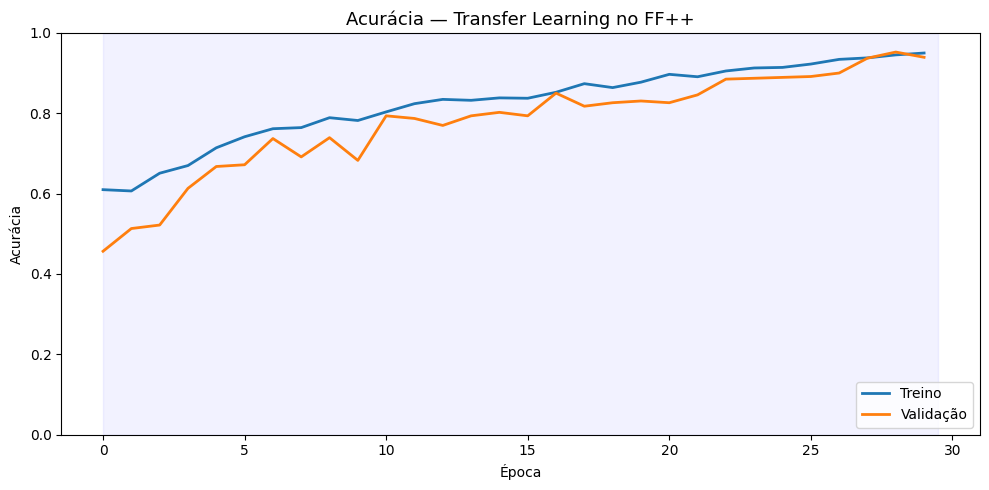

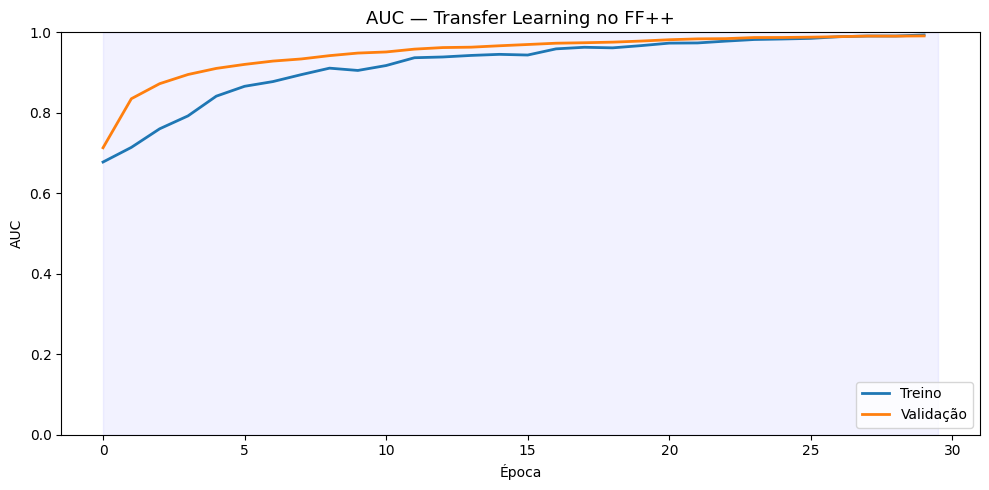

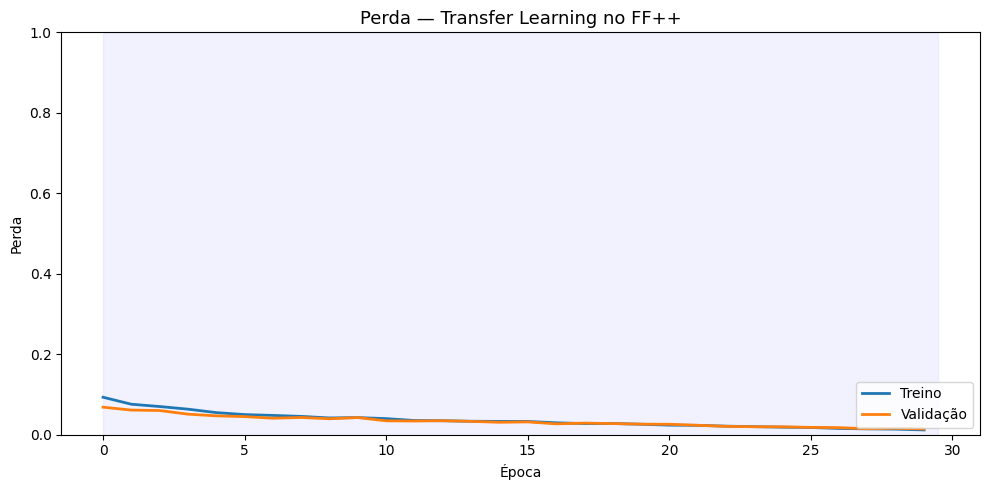

In [74]:
# @title Plota métricas de treino e validação (modelo temporal)

import matplotlib.pyplot as plt


acc_all     = history_temporal.history['accuracy']
val_acc_all = history_temporal.history['val_accuracy']

auc_all     = history_temporal.history['auc']
val_auc_all = history_temporal.history['val_auc']

loss_all     = history_temporal.history['loss']
val_loss_all = history_temporal.history['val_loss']


# Acurácia

plt.figure(figsize=(10, 5))
plt.plot(acc_all,     label='Treino',     linewidth=2)
plt.plot(val_acc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Acurácia — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# AUC

plt.figure(figsize=(10, 5))
plt.plot(auc_all,     label='Treino',     linewidth=2)
plt.plot(val_auc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('AUC — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Loss

plt.figure(figsize=(10, 5))
plt.plot(loss_all,     label='Treino',     linewidth=2)
plt.plot(val_loss_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Perda — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9205 - auc: 0.9825 - loss: 0.0188
Acurácia de teste: 92.05%
AUC-ROC de teste: 0.9825
Perda de teste: 0.0188
🔍 Obtendo predições temporais no test_ds...
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

📊 RELATÓRIO DE AVALIAÇÃO TEMPORAL - CONJUNTO DE TESTE
 • Acurácia Global:      92.05%
 • AUC-ROC:              0.9825
 • F1-Score (Fake):      0.9310
 • Precisão (Fake):      0.9918
 • Revocação / Recall:   0.8773

--- Detalhamento Completo por Classe ---
              precision    recall  f1-score   support

    Real (0)     0.8365    0.9886    0.9062       176
    Fake (1)     0.9918    0.8773    0.9310       277

    accuracy                         0.9205       453
   macro avg     0.9142    0.9329    0.9186       453
weighted avg     0.9315    0.9205    0.9214       453



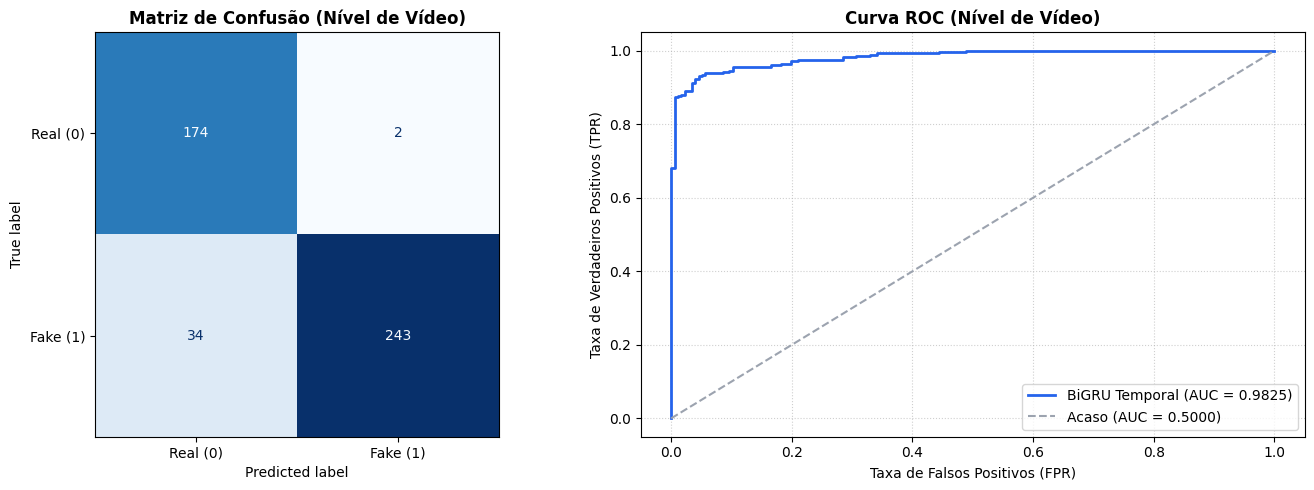

In [84]:
#@title Avaliação do modelo no conjunto de teste

loss, acc, auc = temporal_classifier.evaluate(test_ds_seq)

print(f"Acurácia de teste: {acc * 100:.2f}%")
print(f"AUC-ROC de teste: {auc:.4f}")
print(f"Perda de teste: {loss:.4f}")

def evaluate_temporal_test_dataset(model, test_ds, threshold=0.5):
    print("🔍 Obtendo predições temporais no test_ds...")

    y_true = []
    for _, batch_y in test_ds:
        y_true.extend(batch_y.numpy().flatten())
    y_true = np.array(y_true)


    y_pred_prob = model.predict(test_ds, verbose=1).flatten()
    y_pred_bin = (y_pred_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred_bin)
    auc = roc_auc_score(y_true, y_pred_prob)
    f1 = f1_score(y_true, y_pred_bin)
    prec = precision_score(y_true, y_pred_bin)
    rec = recall_score(y_true, y_pred_bin)

    print("\n" + "=" * 60)
    print("📊 RELATÓRIO DE AVALIAÇÃO TEMPORAL - CONJUNTO DE TESTE")
    print("=" * 60)
    print(f" • Acurácia Global:      {acc * 100:.2f}%")
    print(f" • AUC-ROC:              {auc:.4f}")
    print(f" • F1-Score (Fake):      {f1:.4f}")
    print(f" • Precisão (Fake):      {prec:.4f}")
    print(f" • Revocação / Recall:   {rec:.4f}")
    print("=" * 60)

    print("\n--- Detalhamento Completo por Classe ---")
    print(classification_report(y_true, y_pred_bin, target_names=["Real (0)", "Fake (1)"], digits=4))

    # Plotagem das Figuras
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Matriz de Confusão
    cm = confusion_matrix(y_true, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
    disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Matriz de Confusão (Nível de Vídeo)", fontsize=12, fontweight="bold")
    axes[0].grid(False)

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color="#2563eb", lw=2, label=f"BiGRU Temporal (AUC = {auc:.4f})")
    axes[1].plot([0, 1], [0, 1], color="#9ca3af", lw=1.5, linestyle="--", label="Acaso (AUC = 0.5000)")
    axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=10)
    axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=10)
    axes[1].set_title("Curva ROC (Nível de Vídeo)", fontsize=12, fontweight="bold")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

    return {
        "y_true": y_true,
        "y_pred_prob": y_pred_prob,
        "accuracy": acc,
        "auc_roc": auc,
        "f1_score": f1,
        "confusion_matrix": cm
    }

test_results_temporal = evaluate_temporal_test_dataset(
    model=temporal_classifier,
    test_ds=test_ds_seq,
    threshold=0.5
)

## Modelo frame a frame

In [75]:
# @title Cria datasets de treino, validação e teste (modelo frame a frame)

y_train_2d = y_train.reshape(-1, 1)
y_val_2d = y_val.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

ds1 = tf.data.Dataset.from_tensor_slices((X_train, y_train_2d)) \
    .shuffle(len(X_train)) \
    .batch(BATCH_SIZE, drop_remainder=True)

ds2 = tf.data.Dataset.from_tensor_slices((X_train, y_train_2d)) \
    .shuffle(len(X_train)) \
    .batch(BATCH_SIZE, drop_remainder=True)

train_ds = tf.data.Dataset.zip((ds1, ds2)) \
    .map(lambda b1, b2: apply_early_stopped_mixup(b1, b2, alpha=0.2), num_parallel_calls=tf.data.AUTOTUNE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val_2d)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test_2d)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

In [76]:
#@title Treinamento do modelo (frame a frame)

FEATURE_DIM = X_train.shape[1]

classifier = m.build_classifier(feature_dim=FEATURE_DIM, l2_reg=LR)

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss= tf.keras.losses.BinaryFocalCrossentropy(apply_class_balancing=True),
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

classifier.summary()

mixup_callback = EarlyStoppedMixupCallback(stop_epoch=5)

callbacks = [
    mixup_callback,
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=6,
        mode='min',
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'best_frame_model.keras',
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    )
]

history = classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print(f'\nAcurácia de validação: {history.history["val_accuracy"][-1]:.1%}')

Model: "deepfake_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features_input (InputLayer)     │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sigmoid_output (Dense)          │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,889 (898.00 KB)

 Trainable params: 229,889 (898.00 KB)

 Non-trainable params: 0 (0.00 B)


🔀 [Early-Stopped Mixup] Época 1: Mixup ATIVO. Extraindo características raras.
Epoch 1/30
4834/4847 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5510 - auc: 0.6623 - loss: 0.0936
Epoch 1: val_loss improved from None to 0.06138, saving model to best_frame_model.keras

Epoch 1: finished saving model to best_frame_model.keras
4847/4847 ━━━━━━━━━━━━━━━━━━━━ 28s 4ms/step - accuracy: 0.5740 - auc: 0.7310 - loss: 0.0803 - val_accuracy: 0.8299 - val_auc: 0.8540 - val_loss: 0.0614 - learning_rate: 1.0000e-04

🔀 [Early-Stopped Mixup] Época 2: Mixup ATIVO. Extraindo características raras.
Epoch 2/30
4837/4847 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5961 - auc: 0.8101 - loss: 0.0589
Epoch 2: val_loss improved from 0.06138 to 0.05084, saving model to best_frame_model.keras

Epoch 2: finished saving model to best_frame_model.keras
4847/4847 ━━━━━━━━━━━━━━━━━━━━ 22s 4ms/step - accuracy: 0.5993 - auc: 0.8221 - loss: 0.0555 - val_accuracy: 0.7884 - val_auc: 0.8748 - val_loss: 0.0508 - learnin

In [77]:
#@title Avaliação do modelo (frame a frame)

val_preds = classifier.predict(val_ds)
val_preds_binary = (val_preds >= 0.5).astype(int)

print("\n--- Relatório de Classificação")
print(classification_report(y_val, val_preds_binary, target_names=['Real', 'Fake']))

print("\n--- Matriz de Confusão ---")
print(confusion_matrix(y_val, val_preds_binary))

1003/1003 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

--- Relatório de Classificação
              precision    recall  f1-score   support

        Real       0.50      0.75      0.60      6004
        Fake       0.94      0.83      0.88     26064

    accuracy                           0.81     32068
   macro avg       0.72      0.79      0.74     32068
weighted avg       0.85      0.81      0.83     32068


--- Matriz de Confusão ---
[[ 4526  1478]
 [ 4514 21550]]


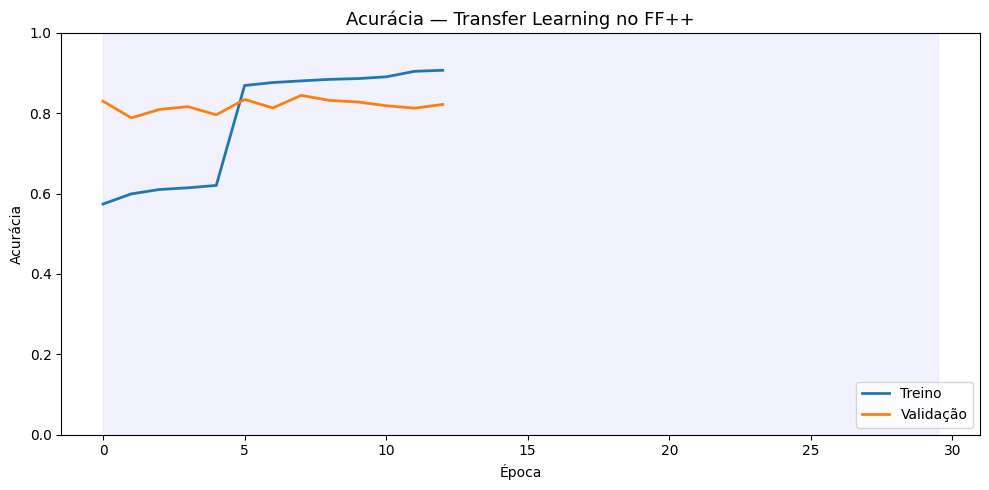

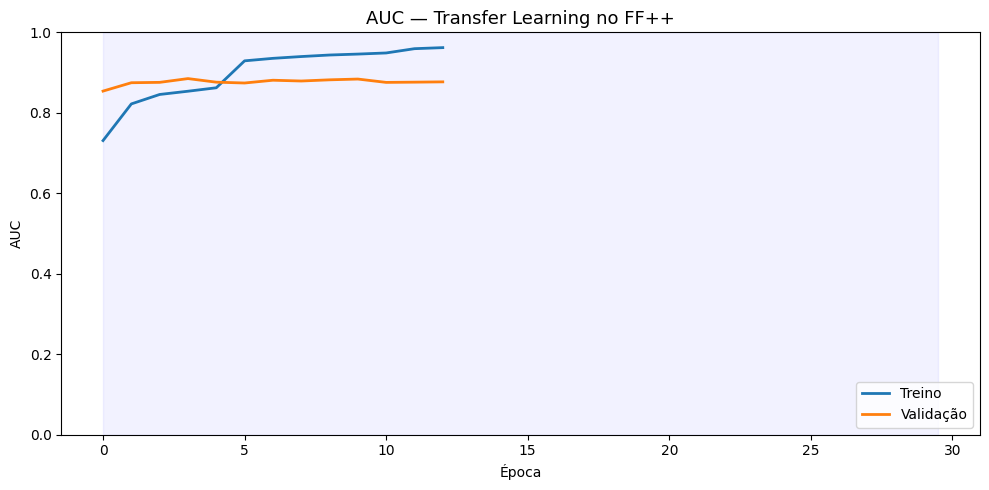

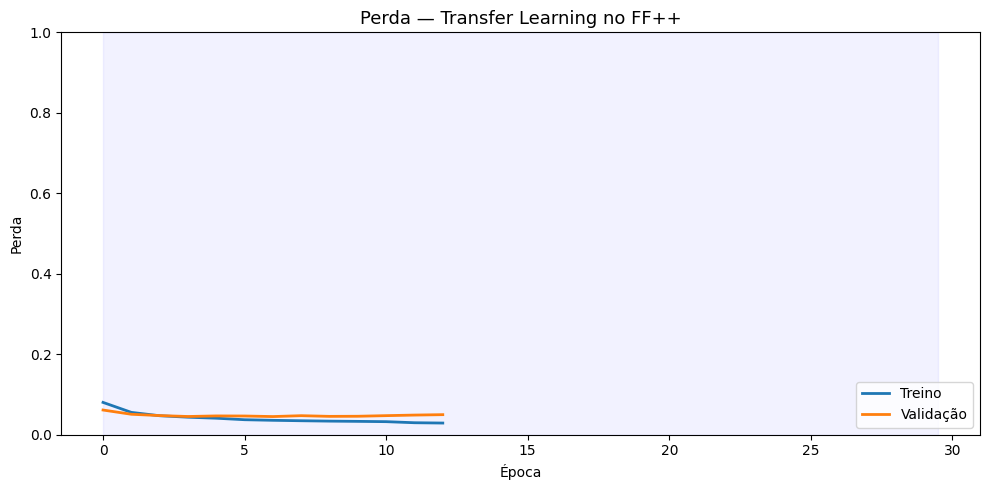

In [78]:
# @title Plota métricas de treino e validação

import matplotlib.pyplot as plt


acc_all     = history.history['accuracy']
val_acc_all = history.history['val_accuracy']

auc_all     = history.history['auc']
val_auc_all = history.history['val_auc']

loss_all     = history.history['loss']
val_loss_all = history.history['val_loss']


# Acurácia

plt.figure(figsize=(10, 5))
plt.plot(acc_all,     label='Treino',     linewidth=2)
plt.plot(val_acc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Acurácia — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# AUC

plt.figure(figsize=(10, 5))
plt.plot(auc_all,     label='Treino',     linewidth=2)
plt.plot(val_auc_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('AUC — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('AUC')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Loss

plt.figure(figsize=(10, 5))
plt.plot(loss_all,     label='Treino',     linewidth=2)
plt.plot(val_loss_all, label='Validação',  linewidth=2)
plt.fill_betweenx([0, 1], 0, EPOCHS - 0.5,
                  alpha=0.05, color='blue')
plt.title('Perda — Transfer Learning no FF++', fontsize=13)
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()




In [85]:
#@title Avaliação do modelo no conjunto de teste

loss, acc, auc = classifier.evaluate(test_ds)

print(f"Acurácia de teste: {acc * 100:.2f}%")
print(f"AUC-ROC de teste: {auc:.4f}")
print(f"Perda de teste: {loss:.4f}")

1078/1078 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7548 - auc: 0.8150 - loss: 0.0543
Acurácia de teste: 75.48%
AUC-ROC de teste: 0.8150
Perda de teste: 0.0543


🔍 Obter predições do modelo no test_ds...
1078/1078 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

📊 RELATÓRIO DE AVALIAÇÃO - CONJUNTO DE TESTE
 • Acurácia:          75.48%
 • AUC-ROC:           0.8150
 • F1-Score:          0.8391
 • Precisão:          0.9279
 • Revocação (Recall): 0.7657


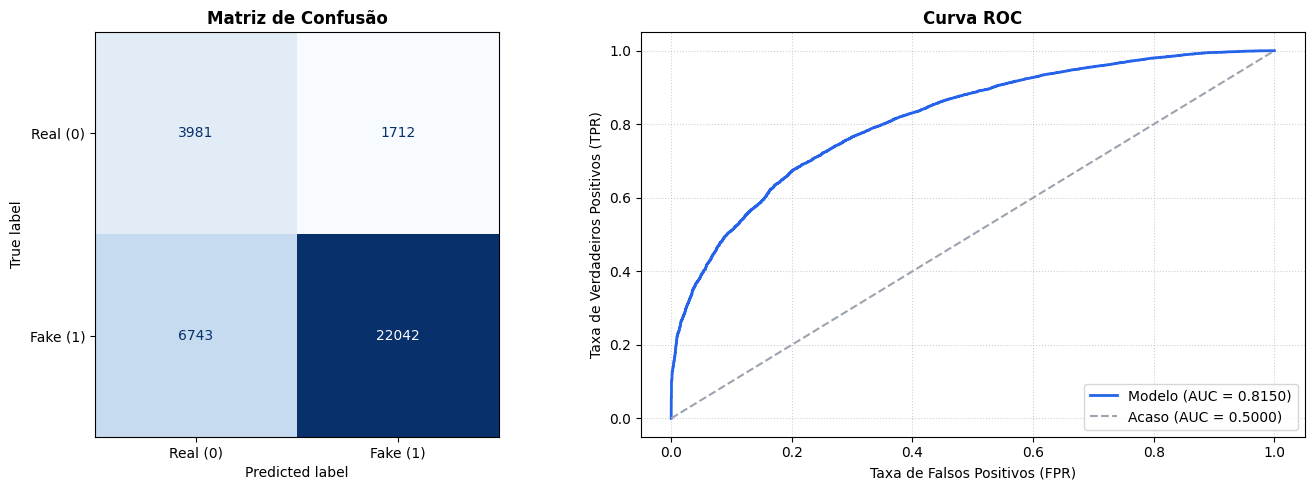

In [86]:
# @title Predição no conjunto de teste

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

def evaluate_test_dataset(model, test_ds, threshold=0.5):
    print("🔍 Obter predições do modelo no test_ds...")

    y_true = []
    for _, batch_y in test_ds:
        y_true.extend(batch_y.numpy().flatten())
    y_true = np.array(y_true)

    y_pred_prob = model.predict(test_ds, verbose=1).flatten()

    y_pred_bin = (y_pred_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred_bin)
    auc = roc_auc_score(y_true, y_pred_prob)
    f1 = f1_score(y_true, y_pred_bin)
    prec = precision_score(y_true, y_pred_bin)
    rec = recall_score(y_true, y_pred_bin)

    print("\n" + "=" * 55)
    print("📊 RELATÓRIO DE AVALIAÇÃO - CONJUNTO DE TESTE")
    print("=" * 55)
    print(f" • Acurácia:          {acc * 100:.2f}%")
    print(f" • AUC-ROC:           {auc:.4f}")
    print(f" • F1-Score:          {f1:.4f}")
    print(f" • Precisão:          {prec:.4f}")
    print(f" • Revocação (Recall): {rec:.4f}")
    print("=" * 55)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(y_true, y_pred_bin)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real (0)", "Fake (1)"])
    disp.plot(ax=axes[0], cmap="Blues", values_format="d", colorbar=False)
    axes[0].set_title("Matriz de Confusão", fontsize=12, fontweight="bold")
    axes[0].grid(False)

    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    axes[1].plot(fpr, tpr, color="#2563eb", lw=2, label=f"Modelo (AUC = {auc:.4f})")
    axes[1].plot([0, 1], [0, 1], color="#9ca3af", lw=1.5, linestyle="--", label="Acaso (AUC = 0.5000)")
    axes[1].set_xlabel("Taxa de Falsos Positivos (FPR)", fontsize=10)
    axes[1].set_ylabel("Taxa de Verdadeiros Positivos (TPR)", fontsize=10)
    axes[1].set_title("Curva ROC", fontsize=12, fontweight="bold")
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()

    return {
        "y_true": y_true,
        "y_pred_prob": y_pred_prob,
        "accuracy": acc,
        "auc_roc": auc,
        "f1_score": f1,
        "confusion_matrix": cm
    }

test_results = evaluate_test_dataset(classifier, test_ds, threshold=0.5)